# Transformaciones geométricas y cambio de perspectiva

**Duración estimada:** 60 minutos

## Objetivo

En este cuaderno vas a rectificar una carta fotografiada en perspectiva para verla de frente. Además, vamos a insistir con la lectura de coordenadas porque este tipo de transformación depende directamente de elegir puntos en la posición correcta.


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


CARPETA_IMAGENES = Path("Imagenes")


def abrir_imagen_bgr(nombre_archivo):
    """Abre una imagen en color usando el orden BGR de OpenCV."""
    ruta = CARPETA_IMAGENES / nombre_archivo
    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)
    if imagen_bgr is None:
        raise FileNotFoundError(f"No pude abrir la imagen: {ruta}")
    return imagen_bgr


def abrir_imagen_rgb(nombre_archivo):
    """Abre una imagen y la convierte a RGB para mostrarla con Matplotlib."""
    imagen_bgr = abrir_imagen_bgr(nombre_archivo)
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    return imagen_rgb


def preparar_eje_imagen(eje, imagen, titulo, mapa=None):
    """Muestra una imagen conservando ejes y coordenadas visibles."""
    eje.imshow(imagen, cmap=mapa)
    eje.set_title(titulo, loc="left", fontweight="bold")
    eje.set_xlabel("x (columnas)")
    eje.set_ylabel("y (filas)")

    if imagen.ndim == 2:
        alto, ancho = imagen.shape
    else:
        alto, ancho = imagen.shape[:2]

    paso_x = max(50, ancho // 6)
    paso_y = max(50, alto // 6)
    eje.set_xticks(np.arange(0, ancho + 1, paso_x))
    eje.set_yticks(np.arange(0, alto + 1, paso_y))
    eje.grid(color="white", alpha=0.25, linewidth=0.6)


def mostrar_una_imagen(imagen, titulo, mapa=None, tamano=(8, 6)):
    fig, eje = plt.subplots(figsize=tamano, constrained_layout=True)
    preparar_eje_imagen(eje, imagen, titulo, mapa)
    plt.show()


def mostrar_varias_imagenes(imagenes, titulos, mapas=None, tamano=(15, 5)):
    if mapas is None:
        mapas = [None] * len(imagenes)

    fig, ejes = plt.subplots(1, len(imagenes), figsize=tamano, constrained_layout=True)
    if len(imagenes) == 1:
        ejes = [ejes]

    for eje, imagen, titulo, mapa in zip(ejes, imagenes, titulos, mapas):
        preparar_eje_imagen(eje, imagen, titulo, mapa)

    plt.show()


def mostrar_histograma_gris(imagen_gris, titulo):
    histograma, bordes = np.histogram(imagen_gris.ravel(), bins=256, range=(0, 256))
    plt.figure(figsize=(9, 4))
    plt.plot(bordes[:-1], histograma, color="black")
    plt.title(titulo, loc="left", fontweight="bold")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")
    plt.grid(alpha=0.3)
    plt.xlim(0, 255)
    plt.show()


def mostrar_histogramas_bgr(imagen_bgr, titulo_general):
    nombres = ["azul", "verde", "rojo"]
    colores = ["tab:blue", "tab:green", "tab:red"]
    fig, ejes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

    for indice in range(3):
        histograma = cv2.calcHist([imagen_bgr], [indice], None, [256], [0, 256]).ravel()
        ejes[indice].plot(histograma, color=colores[indice])
        ejes[indice].set_title(f"Canal {nombres[indice]}", loc="left", fontweight="bold")
        ejes[indice].set_xlabel("Intensidad")
        ejes[indice].set_ylabel("Frecuencia")
        ejes[indice].grid(alpha=0.25)

    fig.suptitle(titulo_general, x=0.01, ha="left", fontweight="bold")
    plt.show()



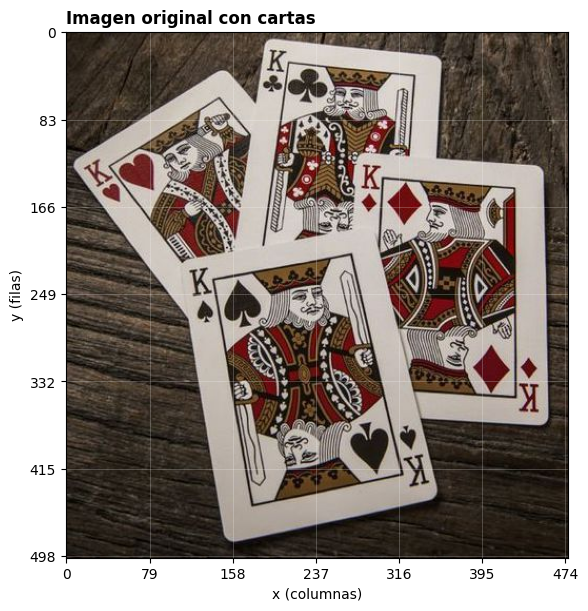

In [2]:
imagen_rgb = abrir_imagen_rgb("cards.jpg")

mostrar_una_imagen(imagen_rgb, "Imagen original con cartas")

## 1. Elegir puntos de origen

Para corregir perspectiva no alcanza con decir “quiero esa carta”. Necesitamos identificar cuatro esquinas en la imagen original. Esas coordenadas van a funcionar como los puntos de origen.


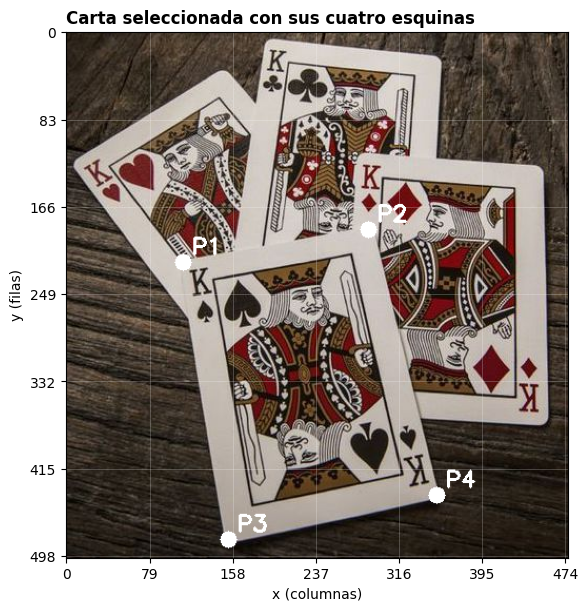

In [3]:
esquinas_origen = np.array(
    [
        [111, 219],
        [287, 188],
        [154, 482],
        [352, 440],
    ],
    dtype=np.float32,
)

imagen_con_esquinas = imagen_rgb.copy()

for numero, punto in enumerate(esquinas_origen, start=1):
    x = int(punto[0])
    y = int(punto[1])
    cv2.circle(imagen_con_esquinas, (x, y), 8, (255, 255, 255), -1)
    cv2.putText(imagen_con_esquinas, f"P{numero}", (x + 8, y - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

mostrar_una_imagen(imagen_con_esquinas, "Carta seleccionada con sus cuatro esquinas")


## 2. Construir la imagen de destino

Ahora definimos cómo queremos ver esa carta después de corregir la perspectiva: un rectángulo ordenado y frontal. Esos van a ser los puntos de destino.


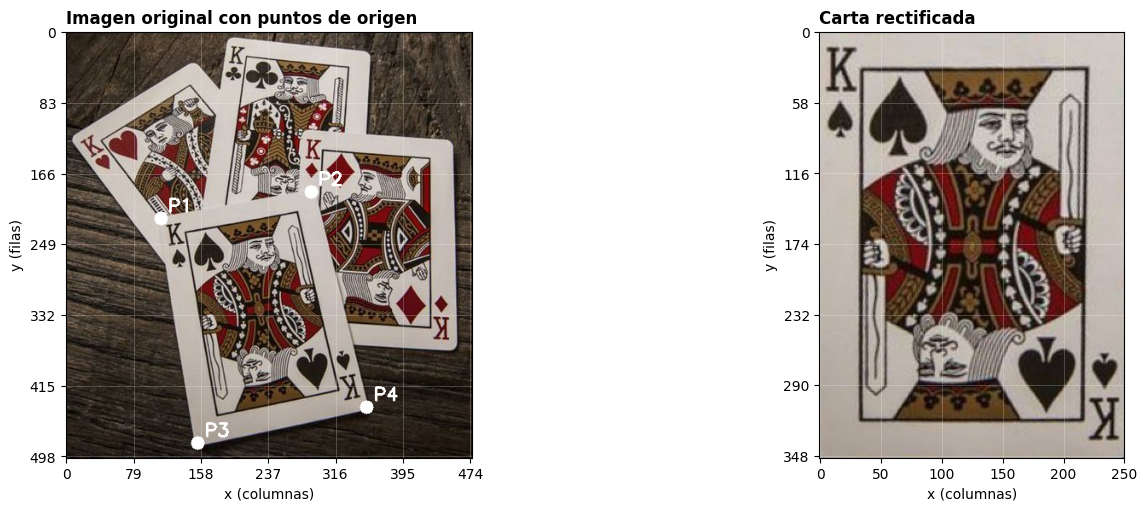

Matriz de perspectiva:
[[ 1.51400e+00 -2.48000e-01 -1.13853e+02]
 [ 2.90000e-01  1.64800e+00 -3.93230e+02]
 [-0.00000e+00  1.00000e-03  1.00000e+00]]


In [4]:
ancho_salida = 250
alto_salida = 350

esquinas_destino = np.array(
    [
        [0, 0],
        [ancho_salida, 0],
        [0, alto_salida],
        [ancho_salida, alto_salida],
    ],
    dtype=np.float32,
)

matriz_perspectiva = cv2.getPerspectiveTransform(esquinas_origen, esquinas_destino)
imagen_rectificada = cv2.warpPerspective(imagen_rgb, matriz_perspectiva, (ancho_salida, alto_salida))

mostrar_varias_imagenes(
    [imagen_con_esquinas, imagen_rectificada],
    ["Imagen original con puntos de origen", "Carta rectificada"],
    tamano=(14, 5),
)

print("Matriz de perspectiva:")
print(matriz_perspectiva.round(3))


## Cierre

En este tipo de tarea, las coordenadas son parte central del procedimiento. Si cambiás los puntos, cambia por completo la rectificación. Por eso conviene mirar siempre la imagen con ejes visibles mientras estás aprendiendo.
